In [9]:
import pandas as pd
import numpy as np

column_names = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

file_path = 'data/imports-85.data' 

df = pd.read_csv(file_path, header=None, names=column_names)

display(df.head())

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [10]:
df.replace('?', np.nan, inplace=True)

missing_data = df.isnull().sum()
print("Кількість пропусків по стовпцях:")
print(missing_data[missing_data > 0])

Кількість пропусків по стовпцях:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


In [11]:
columns_to_convert = ['price', 'horsepower', 'peak-rpm', 'bore', 'stroke', 'normalized-losses']

for col in columns_to_convert:
    if col in df.columns:
        df[col] = df[col].astype("float")

print("\nТипи даних після конвертації:")
print(df.dtypes)


Типи даних після конвертації:
symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


In [12]:
if 'price' in df.columns:
    df.dropna(subset=['price'], axis=0, inplace=True)
    df.reset_index(drop=True, inplace=True)

numeric_cols_with_na = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in numeric_cols_with_na:
    if col in df.columns:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)

categorical_cols_with_na = ['num-of-doors']
for col in categorical_cols_with_na:
    if col in df.columns:
        mode_value = df[col].value_counts().idxmax()
        df[col].fillna(mode_value, inplace=True)

print("\nКількість пропусків після очистки:")
print(df.isnull().sum().max())


Кількість пропусків після очистки:
37


/tmp/ipykernel_7286/2286418089.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(median_value, inplace=True)
/tmp/ipykernel_7286/2286418089.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to updat

In [13]:
duplicates = df.duplicated().sum()
print(f"\nЗнайдено дублікатів: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print("Дублікати успішно видалено.")


Знайдено дублікатів: 0


Text(0.5, 1.0, 'Залежність ціни від потужності')

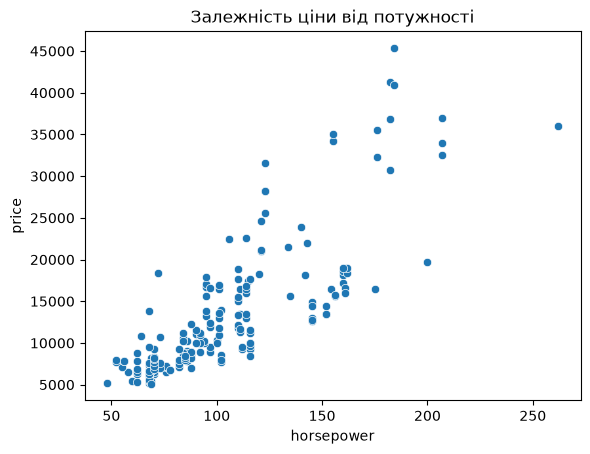

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x='horsepower', y='price')
plt.title('Залежність ціни від потужності')

Text(0, 0.5, 'Кількість')

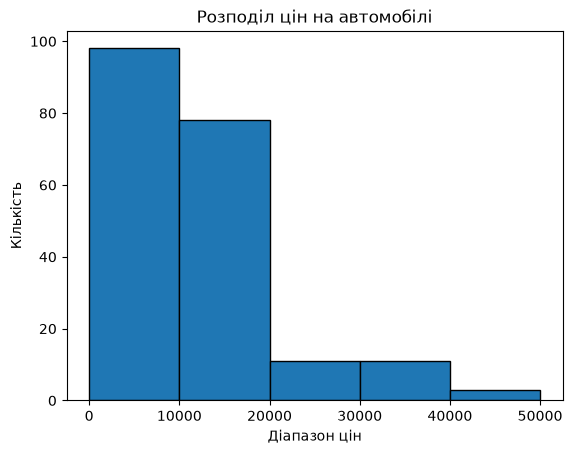

In [15]:
bins = [0, 10000, 20000, 30000, 40000, 50000]
plt.hist(df['price'], bins=bins, edgecolor='black')
plt.title('Розподіл цін на автомобілі')
plt.xlabel('Діапазон цін')
plt.ylabel('Кількість')

<Axes: xlabel='horsepower', ylabel='price'>

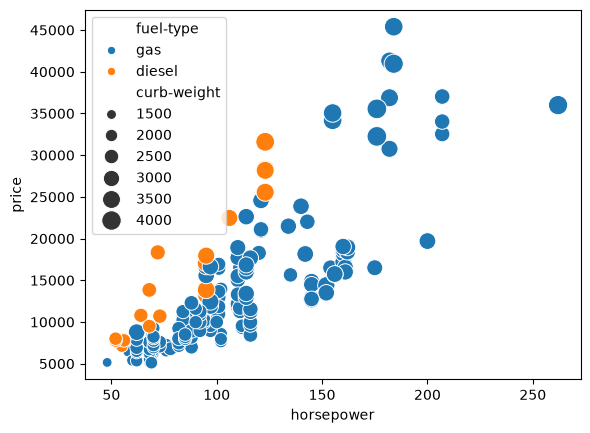

In [16]:
sns.scatterplot(data=df, x='horsepower', y='price', hue='fuel-type', size='curb-weight', sizes=(50, 200))